In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
import networkx as nx

mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['font.size'] = 20
mpl.rcParams['figure.autolayout'] = False
mpl.rcParams['axes.linewidth'] = 3
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['lines.linewidth'] = 2.2
mpl.rcParams['lines.markersize'] = 5
mpl.rcParams['lines.markeredgewidth'] = 1.2
mpl.rcParams['errorbar.capsize'] = 5
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.major.size'] = 8
mpl.rcParams['xtick.minor.width'] = 1.5
mpl.rcParams['xtick.minor.size'] = 6
mpl.rcParams['ytick.minor.width'] = 1.5
mpl.rcParams['ytick.minor.size'] = 6
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['mathtext.fontset'] = 'dejavusans'
mpl.rcParams['font.family'] = 'sans-serif'
cm_colors = plt.get_cmap('Set2')


In [ ]:
import numpy as np
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator, load_graph

from qiskit.circuit.library import qaoa_ansatz
from qiskit import transpile
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator

import matplotlib.pyplot as plt

from qaoa_training_pipeline.evaluation import MPSAerEvaluator, PPEvaluator

chi = 32
mps_evaluator = MPSAerEvaluator({"matrix_product_state_max_bond_dimension": chi})
pp_evaluator = PPEvaluator({"max_weight":6, })

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [ ]:
path = "../../instances/heavy_hex/"
file_name = "000_7_3_heavyhex_144nodes_weighted.json"
import json
with open(path + file_name, "r") as f:
    data = json.load(f)

graph = load_graph(path + file_name)
for i, j in graph.edges:
    graph[i][j]["weight"] = 1


In [5]:
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy
from qopt_best_practices.sat_mapping import SATMapper


swap_strategy = SwapStrategy.from_line(range(graph.order()))
sat_graph, _, layers = SATMapper(timeout=10).remap_graph_with_sat(graph=graph, swap_strategy=swap_strategy)

cost_op_sat = graph_to_operator(sat_graph, pre_factor=-0.5)

In [ ]:
nn = 25
reps = 5
delta_betas = np.linspace(0.1, 2.0, nn)
delta_gammas = np.linspace(0.1, 2.5, nn)
energy_mps = np.zeros((nn, nn))
energy_pp = np.zeros((nn, nn))

for i in range(nn):
    print(f"case {i+1} out of {nn}")
    for j in range(nn):
        delta_beta = delta_betas[i]
        delta_gamma = delta_gammas[j]
        betas = np.arange(1, reps+1)[::-1] * delta_beta / reps
        gammas = np.arange(1, reps+1) * delta_gamma / reps
        params = np.concatenate((betas, gammas)).tolist()
        energy_mps[i][j] = mps_evaluator.evaluate(cost_op_sat, params)
        energy_pp[i][j] = pp_evaluator.evaluate(cost_op_sat, params)
        print(f"energy mps: {energy_mps[i][j]}, energy pp: {energy_pp[i][j]}")

case 1 out of 25
energy mps: 6.859375, energy pp: 8.135352546707434
energy mps: 11.22900390625, energy pp: 14.980242610589963


In [ ]:
np.save("energy_mps_sat_144.npy", energy_mps)
np.save("energy_pp_144.npy", energy_pp)

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")
sampler = SamplerV2(mode=backend)

In [ ]:
nn = 25

list_of_params = []
for i in range(nn):
    print(f"case {i+1} out of {nn}")
    for j in range(nn):
        delta_beta = delta_betas[i]
        delta_gamma = delta_gammas[j]
        betas = np.arange(1, reps+1)[::-1] * delta_beta / reps
        gammas = np.arange(1, reps+1) * delta_gamma / reps
        params = np.concatenate((betas, gammas)).tolist()
        list_of_params.append(params)

reps = 5
cost_op = graph_to_operator(graph, pre_factor=1) 
circuit = qaoa_ansatz(cost_op, reps=reps)
circuit.measure_all()
circuit_transpiled = transpile(circuit, backend)
circuit_transpiled.count_ops()

In [ ]:
job = sampler.run([(circuit_transpiled, params) for params in list_of_params], shots=1000)
id = job.job_id()
print(f"job id: {id}")

In [ ]:
jobs = job.result()
samples = [jobs[i].data.meas.get_counts() for i in range(len(jobs))]

def energy_fun(bitstring, G):
    energy = 0
    for i,j in G.edges:
        if bitstring[i] != bitstring[j]:
            energy -= G[i][j]["weight"]
        else:
            energy += G[i][j]["weight"]
    return energy

energy_list = []
for samples_i in samples:
    energy = 0
    for k, v in samples_i.items():
        energy += v * energy_fun(k[::-1], graph)
    energy /= sum(samples_i.values()) 
    energy_list.append(energy)
np.save(f"energy_qpu_144.npy", energy_list)

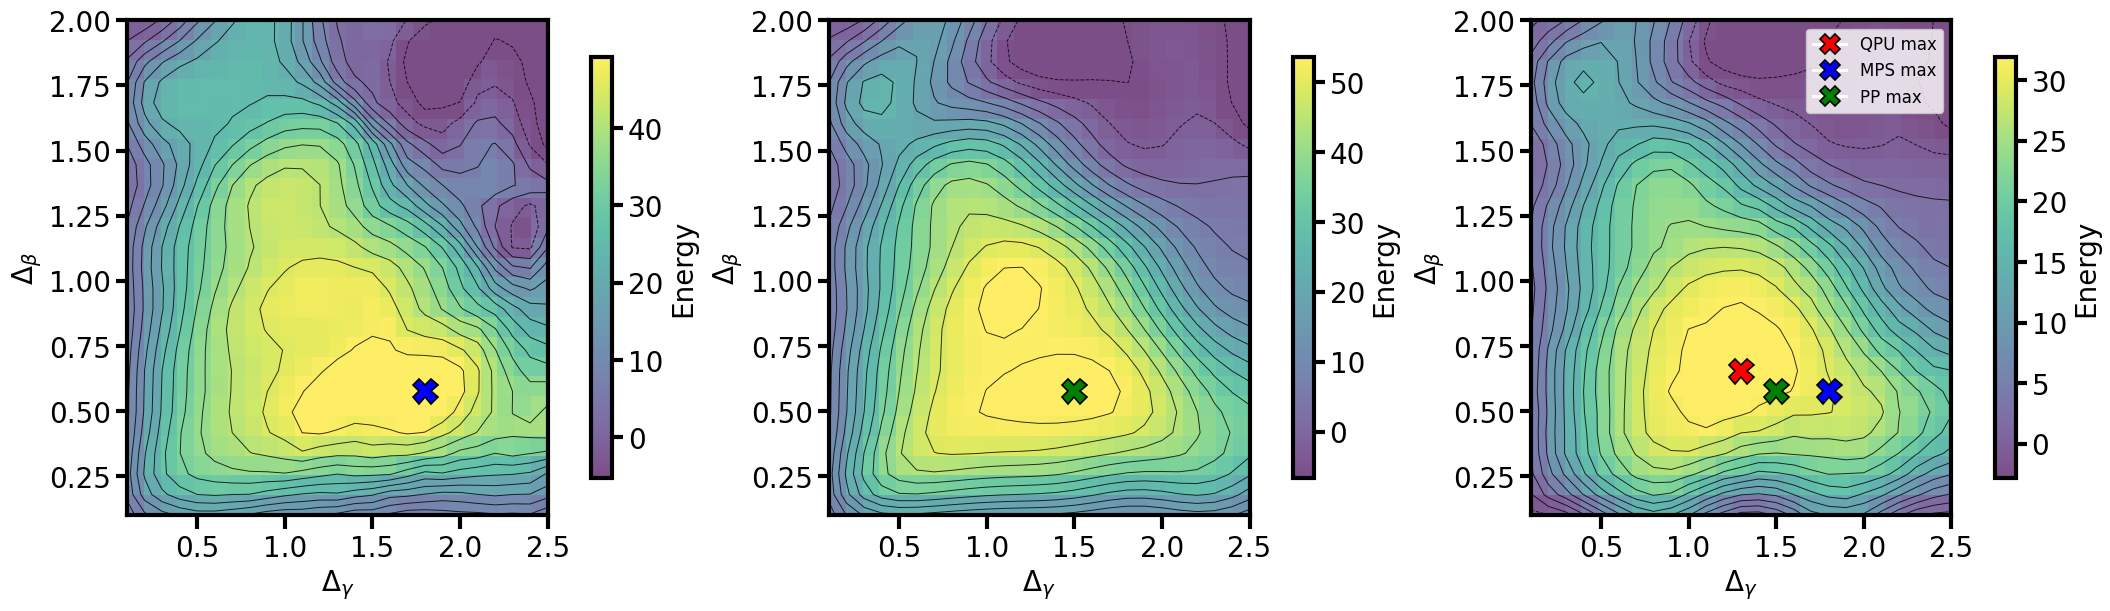

In [4]:
# Overlay imshow and contourf for each plot with its own color scale, 2 rows: energy and differences, with marker at maximum energy in each energy plot, and QPU plot shows also MPS and PP maxima
import numpy as np
import matplotlib.pyplot as plt
import os

energy_mps = np.load("energy_mps_sat_144.npy")
energy_pp = np.load("energy_pp_144.npy")
energy_qpu = np.array(np.load("energy_qpu_144.npy")).reshape(25,25)

nn = energy_mps.shape[0]
deltas = np.linspace(0.1, 2.0, nn)
ps = np.linspace(0.1, 2.5, nn)
X, Y = np.meshgrid(ps, deltas)

cm = 'viridis'
levels_mps = np.linspace(np.percentile(energy_mps, 5), np.percentile(energy_mps, 95), 15)
levels_pp = np.linspace(np.percentile(energy_pp, 5), np.percentile(energy_pp, 95), 15)
if energy_qpu is not None:
    levels_qpu = np.linspace(np.percentile(energy_qpu, 5), np.percentile(energy_qpu, 95), 15)

ncols = 3
nrows = 1
fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows), constrained_layout=True)

def overlay_plot(ax, Z, title, levels, cmap, mark_max=False, extra_maxima=None):
    vmin, vmax = levels[0], levels[-1]
    im = ax.imshow(Z, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[ps[0], ps[-1], deltas[0], deltas[-1]], alpha=0.7)
    cf = ax.contour(X, Y, Z, levels=levels, colors='k', linewidths=0.7, alpha=0.8)
    if mark_max:
        max_idx = np.unravel_index(np.argmax(Z), Z.shape)
        ax.plot(ps[max_idx[1]], deltas[max_idx[0]], marker='X', markeredgecolor="black", color={"QPU":'red', "MPS":"blue", "PP":"green"}[title], markersize=18, label='max')
    if extra_maxima is not None:
        for (idx, color, label) in extra_maxima:
            ax.plot(ps[idx[1]], deltas[idx[0]], marker='X', markeredgecolor="black", color=color, markersize=18, label=label)
    # ax.set_title(title)
    ax.set_xlabel(r'$\Delta_{\gamma}$')
    ax.set_ylabel(r'$\Delta_{\beta}$')
    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label('Energy')
    return im

# Row 1: Energy plots (with max marker)
max_idx_mps = np.unravel_index(np.argmax(energy_mps), energy_mps.shape)
max_idx_pp = np.unravel_index(np.argmax(energy_pp), energy_pp.shape)
im0 = overlay_plot(axes[0], energy_mps, 'MPS', levels_mps, cm, mark_max=True)
im1 = overlay_plot(axes[1], energy_pp, 'PP', levels_pp, cm, mark_max=True)
if energy_qpu is not None:
    # QPU plot: show its own max, plus MPS and PP maxima
    max_idx_qpu = np.unravel_index(np.argmax(energy_qpu), energy_qpu.shape)
    extra_maxima = [
        (max_idx_mps, 'blue', 'MPS max'),
        (max_idx_pp, 'green', 'PP max')
    ]
    im2 = overlay_plot(axes[2], energy_qpu, 'QPU', levels_qpu, cm, mark_max=True, extra_maxima=extra_maxima)
    # Optionally, add legend for markers
    handles = [
        plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='red', markeredgecolor='black', markersize=14, label='QPU max'),
        plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='blue', markeredgecolor='black', markersize=14, label='MPS max'),
        plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='green', markeredgecolor='black', markersize=14, label='PP max'),
    ]
    axes[2].legend(handles=handles, loc='upper right', fontsize=12)
else:
    axes[2].axis('off')

plt.savefig('energy_landscapes_mps_pp_qpu_144_overlay_2row_maxmarker.pdf', transparent=True, bbox_inches='tight')
